In [3]:
import pandas as pd
import numpy as np

In [4]:
#checking if the file exists or not
import os

path = r"C:\Users\Admin\Desktop\InternProject\Zomato_Mumbai_Dataset.csv"

print(os.path.exists(path))

True


In [5]:
#Loading the file from local directory
df = pd.read_csv(r"C:\Users\Admin\Desktop\InternProject\Zomato_Mumbai_Dataset.csv", sep="|",encoding="utf-8",)
df.head(5)


,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",Mumbai,First International Financial Centre-- Bandra ...,https://www.zomato.com/mumbai/hitchki-bandra-k...,1,Casual Dining,12noon to 130am(Mon-Sun),Excellent,4.9,3529
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mumbai,Mahim,https://www.zomato.com/mumbai/baba-falooda-mah...,1,Dessert Parlor,2pm to 1am(Mon-Sun),Very Good,4.4,1723
2,Chin Chin Chu,1800,"Asian,Chinese",Mumbai,Juhu,https://www.zomato.com/mumbai/chin-chin-chu-ju...,1,Casual Dining,12noon to 1am(Mon-Sun),Very Good,4.2,337
3,Butterfly High,1000,Modern Indian,Mumbai,Bandra Kurla Complex,https://www.zomato.com/mumbai/butterfly-high-b...,1,Bar,12noon to 130am(Mon-Sun),Very Good,4.3,1200
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Mumbai,Bandra Kurla Complex,https://www.zomato.com/mumbai/bkc-dive-bandra-...,1,Bar,1130am to 1am(Mon-Sun),Veľmi dobré,4.4,5995


In [6]:
#getting number of data in dataset
df.shape

(15081, 12)

In [7]:
#getting the column names of the dataset
df.columns


Index(['NAME', 'PRICE', 'CUSINE_CATEGORY', 'CITY', 'REGION', 'URL', 'PAGE NO',
       'CUSINE TYPE', 'TIMING', 'RATING_TYPE', 'RATING', 'VOTES'],
      dtype='str')

In [8]:
#Removing unnecessary columns from the dataset
df = df.drop(['CITY','URL','PAGE NO','CUSINE TYPE','TIMING','RATING_TYPE'], axis=1)


In [9]:
df.head(5)

,NAME,PRICE,CUSINE_CATEGORY,REGION,RATING,VOTES
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",First International Financial Centre-- Bandra ...,4.9,3529
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mahim,4.4,1723
2,Chin Chin Chu,1800,"Asian,Chinese",Juhu,4.2,337
3,Butterfly High,1000,Modern Indian,Bandra Kurla Complex,4.3,1200
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra Kurla Complex,4.4,5995


In [10]:
#Getting unique values from 'rating column
display(df['RATING'].unique())

<StringArray>
[    '4.9',     '4.4',     '4.2',     '4.3',     '4.5',     '4.7',     '4.0',
     '4.6',     '4.1',  'RATING',     '3.9',     '3.8',       '-',     '3.6',
     'NEW',     '3.4',     '3.0',     '3.7',     '4.8',     '3.3',     '3.5',
     '3.2',     '3.1',     '2.7',     '2.5',     '2.8',     '2.6',     '2.3',
     '2.9',     '2.4', 'Opening',     '2.1',     '2.2',     '1.8',     '2.0',
       nan]
Length: 36, dtype: str

In [11]:
#Renaming values that have no value in the 'RATING' column (Cleaning / rempoving unnecessar data from the column)
zerovalue = df[(df['RATING'] == '-') | (df['RATING'] == 'NEW') | (df['RATING'] == 'Opening') | (df['RATING'] == 'nan') | (df['RATING'] == 'RATING')].index
df = df.drop(zerovalue)
df.dropna(inplace = True)
df.head(0)

,NAME,PRICE,CUSINE_CATEGORY,REGION,RATING,VOTES


In [12]:
#checking the updated dataframe
display(df["RATING"].unique())

<StringArray>
['4.9', '4.4', '4.2', '4.3', '4.5', '4.7', '4.0', '4.6', '4.1', '3.9', '3.8',
 '3.6', '3.4', '3.0', '3.7', '4.8', '3.3', '3.5', '3.2', '3.1', '2.7', '2.5',
 '2.8', '2.6', '2.3', '2.9', '2.4', '2.1', '2.2', '1.8', '2.0']
Length: 31, dtype: str

In [13]:
display(df['VOTES'])

0        3529
1        1723
2         337
3        1200
4        5995
         ... 
15075     267
15076      64
15077      99
15078      29
15079     121
Name: VOTES, Length: 10767, dtype: str

In [14]:
#removing all the unnecessary data from VOTES i.e [ - ] or having value '0'
zerovote = df[(df['VOTES'] == '-')|(df['VOTES'] == '0')].index
df = df.drop(zerovote)
display(df)

,NAME,PRICE,CUSINE_CATEGORY,REGION,RATING,VOTES
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",First International Financial Centre-- Bandra ...,4.9,3529
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mahim,4.4,1723
2,Chin Chin Chu,1800,"Asian,Chinese",Juhu,4.2,337
3,Butterfly High,1000,Modern Indian,Bandra Kurla Complex,4.3,1200
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra Kurla Complex,4.4,5995
...,...,...,...,...,...,...
15075,Tirupati Balaji,500,"Chinese,Fast Food,North Indian",Oshiwara-- Andheri West,3.5,267
15076,Hari Om Snack Bar,350,"Fast Food,South Indian,Chinese",Kandivali West,3.7,64
15077,PitaBurg,400,"Fast Food,Lebanese",Lower Parel,3.4,99
15078,Uncha Otlawala,300,"Desserts,Ice Cream",Kandivali West,3.5,29


In [15]:
#removing the '.0' from the price section
df['PRICE'] = df['PRICE'].astype(int)
df.head(6)

,NAME,PRICE,CUSINE_CATEGORY,REGION,RATING,VOTES
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",First International Financial Centre-- Bandra ...,4.9,3529
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mahim,4.4,1723
2,Chin Chin Chu,1800,"Asian,Chinese",Juhu,4.2,337
3,Butterfly High,1000,Modern Indian,Bandra Kurla Complex,4.3,1200
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra Kurla Complex,4.4,5995
5,Flea Bazaar Café,800,"American,Asian,Street Food,North Indian,Luckno...",Flea Bazaar Café,4.2,2042


In [16]:
#downlaoding the csv files with data explored and unwanted data removed
df.to_csv('ZomatoDataStep1.csv',index=False)

In [17]:
#importing all the necessary libraries
import pandas as pd
import numpy as np

In [18]:
#loading the region files
df = pd.read_csv(r"C:\InternProject\ZomatoDataStep1.csv",encoding='latin-1')
dfs = pd.read_csv(r"C:\InternProject\MumbaiStations.csv",encoding='latin-1')
dfthanearea = pd.read_csv(r"C:\InternProject\ThaneArea.csv",encoding='latin-1')
dfmumbaiarea = pd.read_csv(r"C:\InternProject\SouthBombayArea.csv",encoding='latin-1')

In [19]:
#getting unique data from region column
np.sort(df['REGION'].unique())

array(['4 Bungalows', '7 Bungalows-- Andheri West',
       'Abbott Hotel-- Vashi', 'Airoli', 'Alibaug', 'Ambernath',
       'Andheri Lokhandwala-- Andheri West', 'Annex Mall-- Borivali East',
       'Atria Mall-- Worli', 'Aureole Hotel-- Andheri East', 'Azad Nagar',
       'Bandra East', 'Bandra Kurla Complex',
       'Bandra Talao-- Bandra West', 'Bandstand-- Bandra West',
       'Bar Bank-- Juhu', 'Bhandup', 'Bhayandar',
       'Big Shopping Centre-- Owale-- Thane West', 'Borivali East',
       'Borivali West', 'Boulevard Mall-- Majiwada-- Thane West',
       'Breach Candy', 'Byculla', 'CBD-Belapur',
       'CR2 Mall-- Nariman Point', 'Carter Road-- Bandra West',
       'Castle Mill-- Thane West', 'Centrium Mall-- Kandivali East',
       'Chakala', 'Chandivali', 'Charni Road', 'Chembur', 'Chowpatty',
       'Churchgate', 'Citizen Hotel-- Juhu', 'Colaba',
       'Comfort Inn Heritage-- Byculla', 'Cooling Tower-- Goregaon East',
       'Cuffe Parade', 'Dadar East', 'Dadar Shivaji Park'

In [20]:
#changing the region Bandra Kurla Complex
loc_lst=df['REGION'].tolist()
for j in loc_lst:
  if (j == 'Bandra Kurla Complex' or j == 'Bandra Kurla Complex, Mumbai'):
    df.replace(j, 'BKC' , inplace = True)
display(df)

,NAME,PRICE,CUSINE_CATEGORY,REGION,RATING,VOTES
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",First International Financial Centre-- Bandra ...,4.9,3529
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mahim,4.4,1723
2,Chin Chin Chu,1800,"Asian,Chinese",Juhu,4.2,337
3,Butterfly High,1000,Modern Indian,BKC,4.3,1200
4,BKC DIVE,1200,"North Indian,Chinese,Continental",BKC,4.4,5995
...,...,...,...,...,...,...
10761,Tirupati Balaji,500,"Chinese,Fast Food,North Indian",Oshiwara-- Andheri West,3.5,267
10762,Hari Om Snack Bar,350,"Fast Food,South Indian,Chinese",Kandivali West,3.7,64
10763,PitaBurg,400,"Fast Food,Lebanese",Lower Parel,3.4,99
10764,Uncha Otlawala,300,"Desserts,Ice Cream",Kandivali West,3.5,29


In [21]:
#creating a list of station column in station dataframe
#now converting the region names to nearby station names
#then getting unique values

st_lst=dfs['Station'].tolist()
region_lst = df['REGION'].tolist()
for i in st_lst:
  for j in region_lst:
    if(i in j):
      df.replace(j, i,inplace=True)
np.sort(df['REGION'].unique())

array(['4 Bungalows', 'Airoli', 'Alibaug', 'Ambernath', 'Andheri',
       'Atria Mall-- Worli', 'Azad Nagar', 'BKC', 'Bandra', 'Bhandup',
       'Bhayandar', 'Borivali', 'Breach Candy', 'Byculla', 'CBD Belapur',
       'CBD-Belapur', 'CR2 Mall-- Nariman Point', 'Chakala', 'Chandivali',
       'Charni Road', 'Chembur', 'Chowpatty', 'Churchgate', 'Colaba',
       'Cuffe Parade', 'Dadar', 'Dahisar', 'Dattani Square Mall-- Vasai',
       'De Mall-- Veera Desai Area', 'Devanshi Inn-- Kalamboli',
       'Dombivali East', 'Dombivali West', 'Fariyas Hotel-- Colaba',
       'Flea Bazaar CafÃ©', 'Fort', 'Fortune Park Lakecity-- Majiwada',
       'Fun Republic Mall-- Veera Desai Area', 'Ghansoli', 'Ghatkopar',
       'Ghodbunder Road', 'Girgaon Chowpatty', 'Girgaum', 'Gorai',
       'Goregaon', 'Grant Road', 'Hotel Royal Inn-- Khar',
       'Hotel Satkar Residency-- Majiwada', 'Jogeshwari', 'Juhu',
       'Kalamboli', 'Kalbadevi', 'Kalwa', 'Kalyan',
       'Kamala Mills Compound', 'Kamothe', 'Kan

In [22]:
sb_lst=dfmumbaiarea['Area'].tolist()
region_lst = df['REGION'].tolist()
for i in sb_lst:
  for j in region_lst:
    if(i in j):
      df.replace(j, i,inplace=True)
np.sort(df['REGION'].unique())

array(['4 Bungalows', 'Airoli', 'Alibaug', 'Ambernath', 'Andheri',
       'Azad Nagar', 'BKC', 'Bandra', 'Bhandup', 'Bhayandar', 'Borivali',
       'Breach Candy', 'Byculla', 'CBD Belapur', 'CBD-Belapur', 'Chakala',
       'Chandivali', 'Charni Road', 'Chembur', 'Chowpatty', 'Churchgate',
       'Colaba', 'Cuffe Parade', 'Dadar', 'Dahisar',
       'Dattani Square Mall-- Vasai', 'De Mall-- Veera Desai Area',
       'Devanshi Inn-- Kalamboli', 'Dombivali East', 'Dombivali West',
       'Flea Bazaar CafÃ©', 'Fort',
       'Fun Republic Mall-- Veera Desai Area', 'Ghansoli', 'Ghatkopar',
       'Ghodbunder Road', 'Girgaon', 'Girgaum', 'Gorai', 'Goregaon',
       'Grant Road', 'Hotel Royal Inn-- Khar',
       'Hotel Satkar Residency-- Majiwada', 'Jogeshwari', 'Juhu',
       'Kalamboli', 'Kalbadevi', 'Kalwa', 'Kalyan',
       'Kamala Mills Compound', 'Kamothe', 'Kandivali', 'Kemps Corner',
       'Khar', 'Kharghar', 'Kopar', 'Kurla', 'Le Sutra Hotel-- Khar',
       'Mahakali', 'Mahalaxmi', 'M

In [23]:
thane_lst=dfthanearea['Area'].tolist()
region_lst = df['REGION'].tolist()
for i in thane_lst:
  for j in region_lst:
    if(i in j):
      df.replace(j, i,inplace=True)
np.sort(df['REGION'].unique())

array(['4 Bungalows', 'Airoli', 'Alibaug', 'Ambernath', 'Andheri',
       'Azad Nagar', 'BKC', 'Bandra', 'Bhandup', 'Bhayandar', 'Borivali',
       'Breach Candy', 'Byculla', 'CBD Belapur', 'CBD-Belapur', 'Chakala',
       'Chandivali', 'Charni Road', 'Chembur', 'Chowpatty', 'Churchgate',
       'Colaba', 'Cuffe Parade', 'Dadar', 'Dahisar',
       'Dattani Square Mall-- Vasai', 'De Mall-- Veera Desai Area',
       'Devanshi Inn-- Kalamboli', 'Dombivali East', 'Dombivali West',
       'Flea Bazaar CafÃ©', 'Fort',
       'Fun Republic Mall-- Veera Desai Area', 'Ghansoli', 'Ghatkopar',
       'Ghodbunder Road', 'Girgaon', 'Girgaum', 'Gorai', 'Goregaon',
       'Grant Road', 'Hotel Royal Inn-- Khar', 'Jogeshwari', 'Juhu',
       'Kalamboli', 'Kalbadevi', 'Kalwa', 'Kalyan',
       'Kamala Mills Compound', 'Kamothe', 'Kandivali', 'Kemps Corner',
       'Khar', 'Kharghar', 'Kopar', 'Kurla', 'Le Sutra Hotel-- Khar',
       'Mahakali', 'Mahalaxmi', 'Mahim', 'Majiwada', 'Malabar Hill',
       'M

In [24]:
#converting several more regions to their corresponding locatlity
for j in region_lst:
  if (j == 'Dombivali East' or j == 'Dombivali West' or j == 'Kopar' or j == 'Dombivali' or j=='Xperia Mall-- Dombivali East'):
    df.replace(j, 'Dombivli' , inplace = True)

for i in region_lst:
  if (i == 'CBD-Belapur'):
    df.replace(i, 'CBD Belapur' , inplace = True)

for n in region_lst:
  if (n == 'Flea Bazaar CafÃ©' or n == 'Kamala Mills Compound'):
    df.replace(n, 'Parel', inplace = True)

for o in region_lst:
  if (o == 'Runwal Green'):
    df.replace(o, 'Mulund', inplace = True)
    
for p in region_lst:
    if (p=='Dattani Square Mall-- Vasai' or p=='Rudra Shelter International-- Vasai'):
        df.replace(p, 'Vasai', inplace = True)

for q in region_lst:
    if (q=='Fun Republic Mall-- Veera Desai Area' or q=='De Mall-- Veera Desai Area'):
        df.replace(q, 'Andheri', inplace = True)

display(np.sort(df["REGION"].unique()))

array(['4 Bungalows', 'Airoli', 'Alibaug', 'Ambernath', 'Andheri',
       'Azad Nagar', 'BKC', 'Bandra', 'Bhandup', 'Bhayandar', 'Borivali',
       'Breach Candy', 'Byculla', 'CBD Belapur', 'Chakala', 'Chandivali',
       'Charni Road', 'Chembur', 'Chowpatty', 'Churchgate', 'Colaba',
       'Cuffe Parade', 'Dadar', 'Dahisar', 'Devanshi Inn-- Kalamboli',
       'Dombivli', 'Fort', 'Ghansoli', 'Ghatkopar', 'Ghodbunder Road',
       'Girgaon', 'Girgaum', 'Gorai', 'Goregaon', 'Grant Road',
       'Hotel Royal Inn-- Khar', 'Jogeshwari', 'Juhu', 'Kalamboli',
       'Kalbadevi', 'Kalwa', 'Kalyan', 'Kamothe', 'Kandivali',
       'Kemps Corner', 'Khar', 'Kharghar', 'Kurla',
       'Le Sutra Hotel-- Khar', 'Mahakali', 'Mahalaxmi', 'Mahim',
       'Majiwada', 'Malabar Hill', 'Malad', 'Marine Lines', 'Marol',
       'Marve', 'Matunga', 'Mazgaon', 'Mira Road', 'Mohammad Ali Road',
       'Mulund', 'Mumbai CST Area', 'Mumbai Central', 'Mumbra',
       'Nalasopara', 'Nariman Point', 'Nerul',
       '

In [25]:
for n in region_lst:
  if (n == 'Devanshi Inn-- Kalamboli' or n == 'Pallavi Avida-- Kalamboli'):
    df.replace(n, 'Panvel', inplace = True)

for o in region_lst:
    if (o=='Hotel Royal Inn-- Khar' or o=='Le Sutra Hotel-- Khar'):
        df.replace(o, 'Khar', inplace = True)

for p in region_lst:
    if (p=='R Galleria-- Runwal Green'):
        df.replace(p, 'Mulund', inplace = True)    


display(np.sort(df["REGION"].unique()))

array(['4 Bungalows', 'Airoli', 'Alibaug', 'Ambernath', 'Andheri',
       'Azad Nagar', 'BKC', 'Bandra', 'Bhandup', 'Bhayandar', 'Borivali',
       'Breach Candy', 'Byculla', 'CBD Belapur', 'Chakala', 'Chandivali',
       'Charni Road', 'Chembur', 'Chowpatty', 'Churchgate', 'Colaba',
       'Cuffe Parade', 'Dadar', 'Dahisar', 'Dombivli', 'Fort', 'Ghansoli',
       'Ghatkopar', 'Ghodbunder Road', 'Girgaon', 'Girgaum', 'Gorai',
       'Goregaon', 'Grant Road', 'Jogeshwari', 'Juhu', 'Kalamboli',
       'Kalbadevi', 'Kalwa', 'Kalyan', 'Kamothe', 'Kandivali',
       'Kemps Corner', 'Khar', 'Kharghar', 'Kurla', 'Mahakali',
       'Mahalaxmi', 'Mahim', 'Majiwada', 'Malabar Hill', 'Malad',
       'Marine Lines', 'Marol', 'Marve', 'Matunga', 'Mazgaon',
       'Mira Road', 'Mohammad Ali Road', 'Mulund', 'Mumbai CST Area',
       'Mumbai Central', 'Mumbra', 'Nalasopara', 'Nariman Point', 'Nerul',
       'Panvel', 'Parel', 'Peddar Road', 'Powai', 'Prabhadevi',
       'Sakinaka', 'Sanpada', 'Santac

In [26]:
df.to_csv('ZomatoDataStep2.csv', index=False)

In [27]:
#importing all the necessary libraries and file
import pandas as pd
import numpy as np
from collections import defaultdict

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [29]:
df = pd.read_csv(r"C:\InternProject\ZomatoDataStep2.csv",encoding='latin-1')


In [30]:
#now counting all the cusine type in a locality
all_loc=['Airoli', 'Alibaug', 'Ambernath', 'Andheri', 'BKC', 'Bandra',
       'Bhandup', 'Bhayandar', 'Borivali', 'Byculla', 'CBD Belapur',
       'Chembur', 'Dadar', 'Dahisar', 'Dombivli', 'Ghansoli', 'Ghatkopar',
       'Gorai', 'Goregaon', 'Jogeshwari', 'Juhu', 'Kalamboli', 'Kalyan',
       'Kamothe', 'Kandivali', 'Khar', 'Kharghar', 'Kurla', 'Mahim',
       'Malad', 'Marve', 'Matunga', 'Mazgaon', 'Mira Road', 'Mulund',
       'Nalasopara', 'Nerul', 'Panvel', 'Parel', 'Powai', 'Prabhadevi',
       'Sakinaka', 'Sanpada', 'Santacruz', 'Seawoods', 'Sewri', 'Sion',
       'South Bombay', 'Thane', 'Turbhe', 'Ulhasnagar', 'Ulwe', 'Vasai',
       'Vashi', 'Vikhroli', 'Vile Parle', 'Virar', 'Wadala', 'Worli']
cus_dict=defaultdict()
for index,row in df.iterrows():
    if(row["REGION"] in all_loc):
        cstr=row["CUSINE_CATEGORY"]
        lst_cus=cstr.split(",")
        if(row["REGION"] in cus_dict):
            pass
        else:
            cus_dict[row["REGION"]]=defaultdict()
        for d in lst_cus:
            if(d in cus_dict[row["REGION"]]):
                cus_dict[row["REGION"]][d]=cus_dict[row["REGION"]][d]+1
            else:
                cus_dict[row["REGION"]][d]=1
alldata=pd.DataFrame.from_dict(cus_dict, orient ='index') 
alldata=alldata.fillna(0)
display(alldata)

,Modern Indian,North Indian,Chinese,Momos,Biryani,Continental,American,Fast Food,Mexican,Desserts,...,Frozen Yogurt,Fried Chicken,Mongolian,Tamil,Israeli,Cuisine Varies,Armenian,Belgian,Oriya,Raw Meats
Bandra,6.0,111,108,2.0,18.0,23.0,12.0,70,10.0,66.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Juhu,1.0,43,43,0.0,5.0,13.0,6.0,23,6.0,22.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
BKC,1.0,9,5,0.0,3.0,8.0,4.0,8,3.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Parel,4.0,103,85,4.0,4.0,11.0,8.0,74,9.0,44.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Khar,1.0,54,55,5.0,12.0,14.0,5.0,35,2.0,26.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Powai,1.0,117,96,6.0,24.0,12.0,6.0,53,5.0,20.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Chembur,1.0,152,156,3.0,14.0,15.0,2.0,55,5.0,18.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Borivali,1.0,132,133,3.0,19.0,31.0,3.0,115,11.0,34.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Thane,3.0,378,355,19.0,39.0,41.0,15.0,167,21.0,55.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Kandivali,1.0,155,149,2.0,15.0,22.0,3.0,124,9.0,47.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
#changing the index to location column
alldata.index.name = 'Location'
alldata.to_csv('placesandcusine.csv')
alldata.index.name = 'Location'
alldata.to_csv('allplacesandcusine.csv')

In [32]:
dfvisualization = pd.read_csv('placesandcusine.csv')

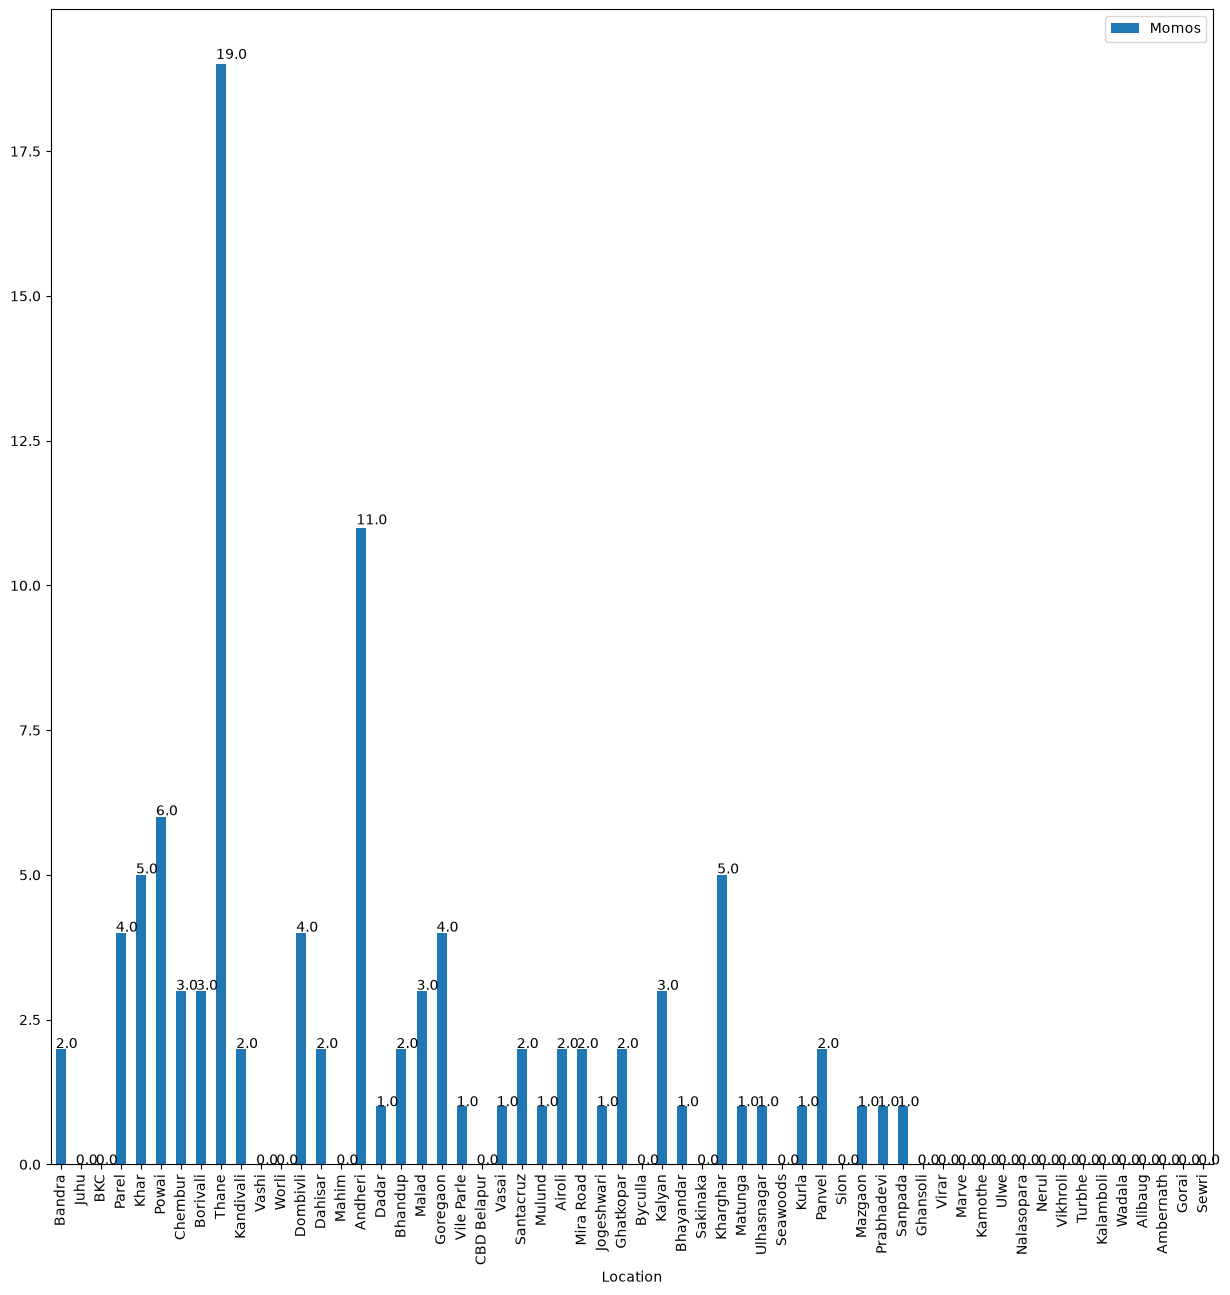

In [40]:
#plotting a count of specic dishes according to the places
nm = pd.read_csv('allplacesandcusine.csv')
#nm.head(5)
list_of_cus=["Momos"]
#nm.plot(x="Location", y=list_of_cus, kind="bar")

#nm.plot(x="Location", y=list_of_cus, kind="bar",figsize=(15, 15))
ax = nm.plot(x="Location", y=list_of_cus, kind="bar",figsize=(15, 15))
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x(), p.get_height()*(1.005)))

Location,Bandra,Juhu,BKC,Parel,Khar,Powai,Chembur,Borivali,Thane,Kandivali,...,Nalasopara,Nerul,Vikhroli,Turbhe,Kalamboli,Wadala,Alibaug,Ambernath,Gorai,Sewri
Modern Indian,6.0,1.0,1.0,4.0,1.0,1.0,1.0,1.0,3.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
North Indian,111.0,43.0,9.0,103.0,54.0,117.0,152.0,132.0,378.0,155.0,...,61.0,68.0,43.0,6.0,25.0,20.0,2.0,16.0,3.0,7.0
Chinese,108.0,43.0,5.0,85.0,55.0,96.0,156.0,133.0,355.0,149.0,...,79.0,65.0,44.0,6.0,28.0,19.0,3.0,16.0,5.0,9.0
Momos,2.0,0.0,0.0,4.0,5.0,6.0,3.0,3.0,19.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Biryani,18.0,5.0,3.0,4.0,12.0,24.0,14.0,19.0,39.0,15.0,...,3.0,12.0,4.0,1.0,0.0,2.0,2.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cuisine Varies,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Armenian,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Belgian,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Oriya,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


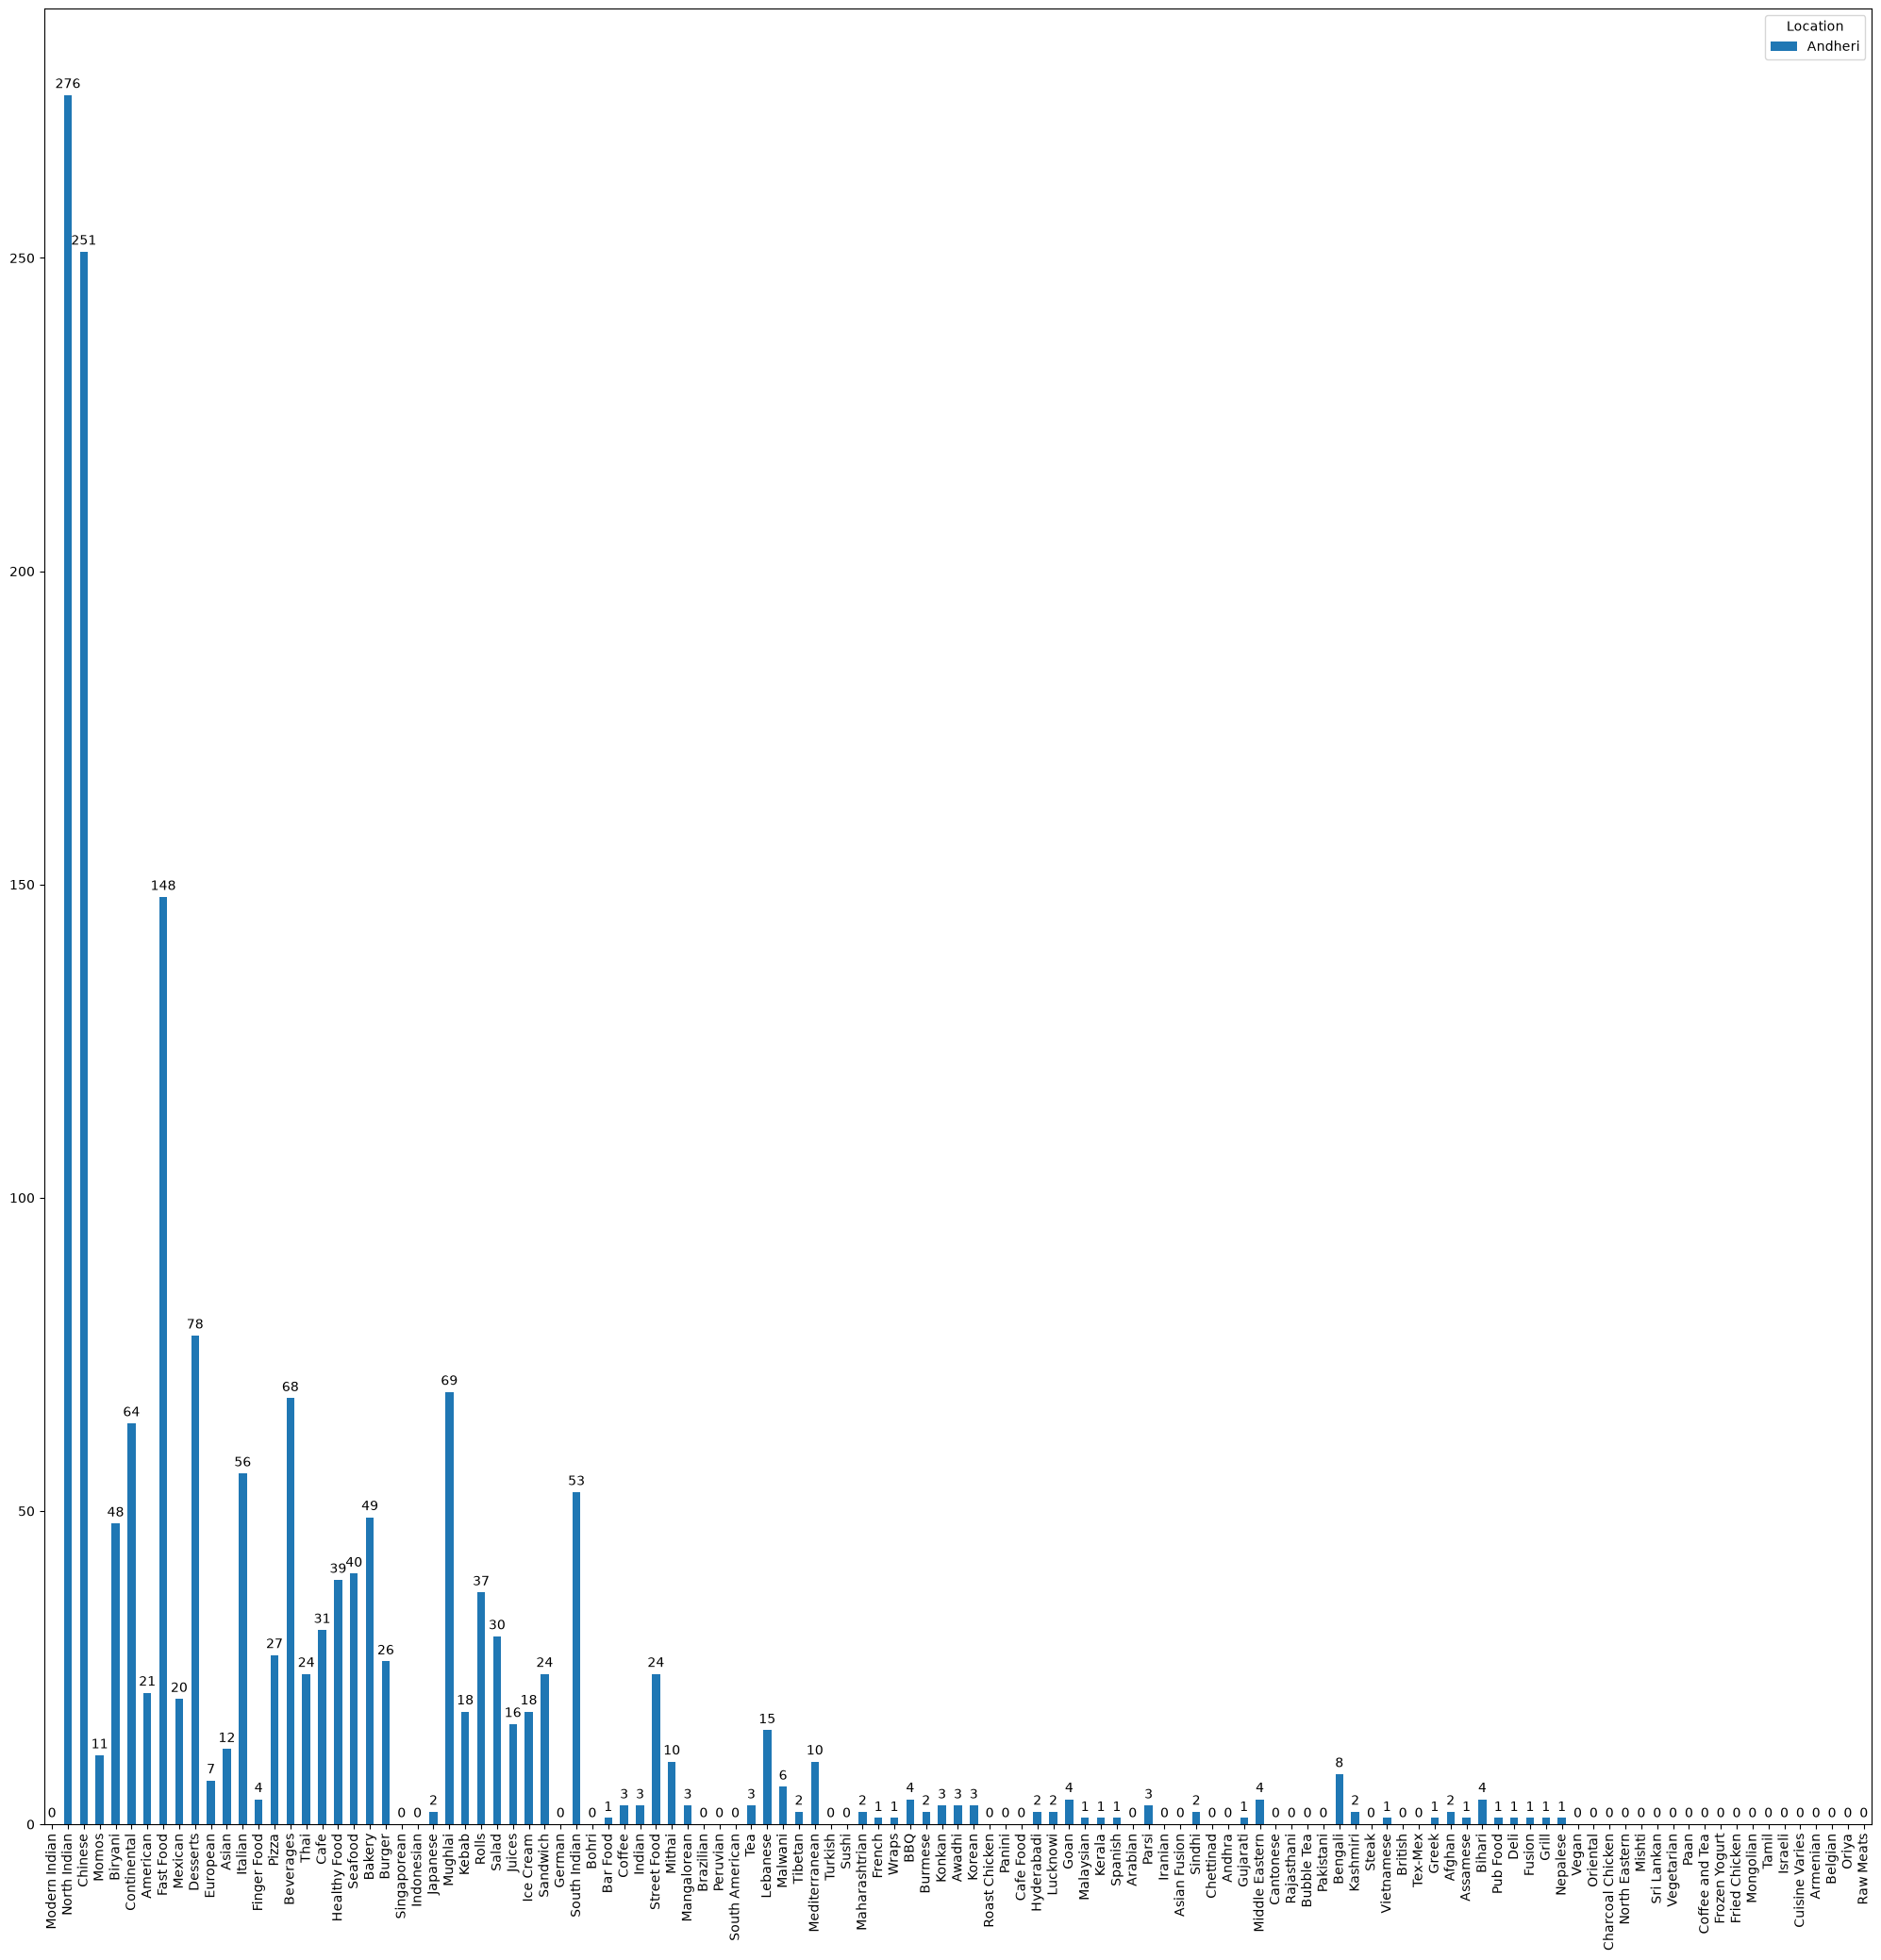

In [34]:
#now for getting the data of cuisine in locality vs locality
newdataset = pd.read_csv('allplacesandcusine.csv')
newdataset.set_index('Location',inplace=True)
newdatasetT = newdataset.transpose()
display(newdatasetT)
#dfnm = pd.DataFrame.from_dict(newdatasetT)
listofloc = ["Andheri"]
ax = newdatasetT.plot(
    y=listofloc,
    kind="bar",
    use_index=True,
    figsize=(25, 25)
)

# Display the number on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10)

plt.show()

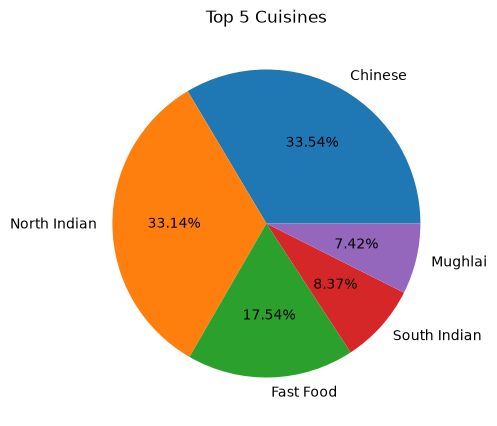

In [35]:
#pie chart for top 5 cuisine
df1 = df['CUSINE_CATEGORY'].str.split(',')
xy = df1.explode().value_counts().nlargest(5)
x = xy.index
y = xy.values/df.count().NAME
plt.figure(figsize=(5, 5))
plt.pie(y,labels=x,autopct='%1.2f%%')
plt.title("Top 5 Cuisines")
plt.show()

In [36]:
print(df.columns.tolist())

['NAME', 'PRICE', 'CUSINE_CATEGORY', 'REGION', 'RATING', 'VOTES']


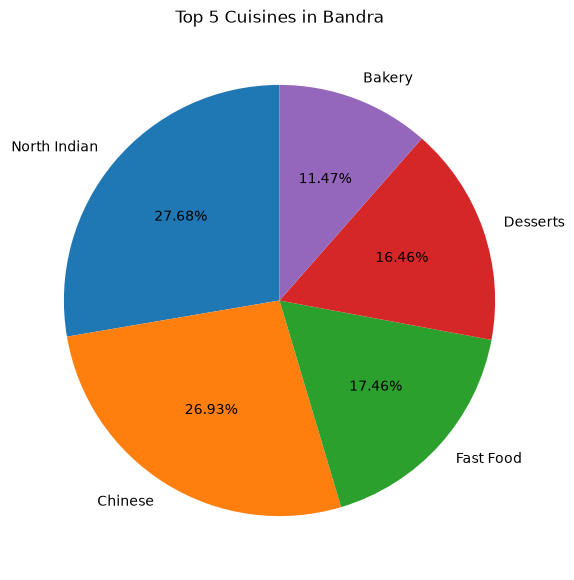

In [37]:
# Select the location you want
place = "Bandra"

# Filter data for that location
place_df = df[df['REGION'].str.strip().str.lower() == place.lower()]

# Split cuisines and count them
cuisines = place_df['CUSINE_CATEGORY'].str.split(',')
cuisine_counts = cuisines.explode().str.strip().value_counts().nlargest(5)

# Pie chart
plt.figure(figsize=(7, 7))
plt.pie(
    cuisine_counts.values,
    labels=cuisine_counts.index,
    autopct='%1.2f%%',
    startangle=90
)

plt.title(f"Top 5 Cuisines in {place}")
plt.show()


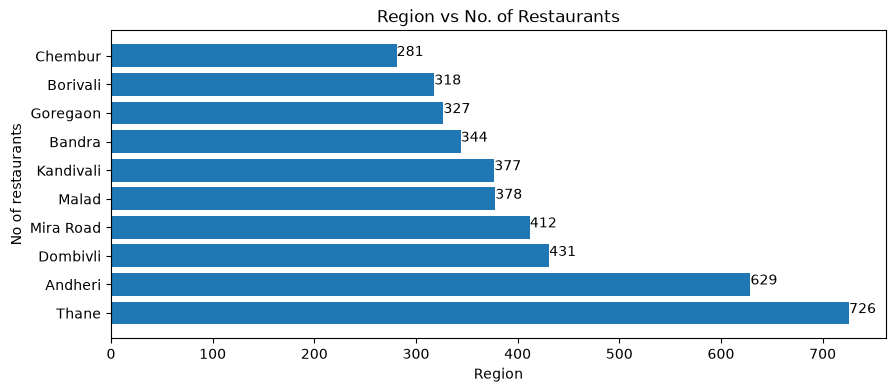

In [38]:
#top regions vs number of restaurants
x = df['REGION'].value_counts().nlargest(10).index
y = df['REGION'].value_counts().nlargest(10).values
plt.figure(figsize=(10, 4))
plt.title("Region vs No. of Restaurants")
plt.ylabel("No of restaurants")
plt.xlabel("Region")
plt.barh(x,y)
for index, value in enumerate(y):
    plt.text(value, index, str(value))
plt.show()

In [39]:
#scatter plot for rate vs price distribution
rating_price_df = df[['PRICE', 'RATING', 'REGION', 'CUSINE_CATEGORY']].dropna()

secondscatterfig = px.scatter(rating_price_df, x="PRICE", y="RATING", color="RATING",size='RATING',hover_data=['REGION','CUSINE_CATEGORY'],title='Rating vs Price distribution').update_traces(marker_size=10)
secondscatterfig.show()